In [1]:
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# --- GLOBAL EXPERIMENT SETTINGS ---
N_QUEENS = 8
POPULATION_SIZE = 100
MAX_GENERATIONS = 100

# --- META-GA TUNED PARAMETERS ---
# These are the optimal values discovered by the Meta-Tuner in Cell 4
TUNED_A_INIT = 0.500
TUNED_R_INIT = 0.238
TUNED_F_MAX = 1.505
TUNED_ALPHA = 0.956
TUNED_GAMMA = 0.032

In [2]:
def fitness_n_queens(board):
    """Calculates total attacking pairs. 0 means perfect solution."""
    board = np.round(board) % len(board)
    conflicts = 0
    n = len(board)
    for i in range(n):
        for j in range(i + 1, n):
            if board[i] == board[j] or abs(board[i] - board[j]) == abs(i - j):
                conflicts += 1
    return conflicts

def smart_initialization(pop_size, n_queens):
    """Spawns 80% random bats, and 20% heuristically optimized bats."""
    positions = []
    for _ in range(int(pop_size * 0.8)): 
        positions.append(np.random.permutation(n_queens))
    for _ in range(int(pop_size * 0.2)): 
        positions.append(np.array(list(range(1, n_queens, 2)) + list(range(0, n_queens, 2))))
    return np.array(positions, dtype=float)

In [3]:
def genetic_algorithm(n_queens=N_QUEENS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """Baseline Genetic Algorithm."""
    population = [np.random.permutation(n_queens) for _ in range(pop_size)]
    best_fitness = float('inf')
    convergence = []
    
    for generation in range(max_gens):
        fitness_scores = [fitness_n_queens(ind) for ind in population]
        min_fit = min(fitness_scores)
        if min_fit < best_fitness: best_fitness = min_fit
            
        convergence.append(best_fitness)
        if best_fitness == 0:
            convergence.extend([0] * (max_gens - generation - 1))
            break
            
        new_population = []
        for _ in range(pop_size // 2):
            tour1 = random.sample(list(zip(population, fitness_scores)), 3)
            tour2 = random.sample(list(zip(population, fitness_scores)), 3)
            p1, p2 = min(tour1, key=lambda x: x[1])[0], min(tour2, key=lambda x: x[1])[0]
            c1, c2 = p1.copy(), p2.copy()
            pt = random.randint(1, n_queens-2)
            c1[pt:], c2[pt:] = c2[pt:].copy(), c1[pt:].copy()
            new_population.extend([c1, c2])
            
        for i in range(pop_size):
            if random.random() < 0.2:
                idx1, idx2 = random.sample(range(n_queens), 2)
                new_population[i][idx1], new_population[i][idx2] = new_population[i][idx2], new_population[i][idx1]
        population = new_population
    return best_fitness, convergence

def standard_bat_algorithm(n_queens=N_QUEENS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """Original Bat Algorithm with arbitrary parameters."""
    positions = np.array([np.random.permutation(n_queens) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_queens))
    A, r = np.ones(pop_size) * 0.9, np.ones(pop_size) * 0.3
    fitness = np.array([fitness_n_queens(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            velocities[i] += (positions[i] - best_position) * random.uniform(0, 2.0)
            if random.random() > r[i]:
                new_pos = best_position + np.random.uniform(-1, 1, n_queens) * np.mean(A)
            else:
                new_pos = positions[i] + velocities[i]
                
            new_fit = fitness_n_queens(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
            curr_div += np.sum((np.round(positions[i]) % n_queens) != (np.round(best_position) % n_queens))
            
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
        if best_fitness == 0:
            convergence.extend([0] * (max_gens - generation - 1))
            diversity.extend([diversity[-1]] * (max_gens - generation - 1))
            break
    return best_fitness, convergence, diversity

def enhanced_bat_algorithm(n_queens=N_QUEENS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS, init_pop=None, a_init=0.9, r_init=0.3, f_max=2.0, alpha=0.9, gamma=0.05):
    """Upgraded Bat Algorithm with Memetic Swaps and Dynamic Decay."""
    positions = init_pop.copy() if init_pop is not None else np.array([np.random.permutation(n_queens) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_queens))
    A, r = np.ones(pop_size) * a_init, np.ones(pop_size) * r_init
    fitness = np.array([fitness_n_queens(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            velocities[i] += (positions[i] - best_position) * random.uniform(0, f_max)
            if random.random() > r[i]:
                new_pos = best_position.copy()
                idx1, idx2 = random.sample(range(n_queens), 2)
                new_pos[idx1], new_pos[idx2] = new_pos[idx2], new_pos[idx1]
            else:
                new_pos = positions[i] + velocities[i]
                
            new_fit = fitness_n_queens(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
            curr_div += np.sum((np.round(positions[i]) % n_queens) != (np.round(best_position) % n_queens))
            
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
        for i in range(pop_size):
            A[i] *= alpha
            r[i] = r_init * (1 - math.exp(-gamma * generation))
            
        if best_fitness == 0:
            convergence.extend([0] * (max_gens - generation - 1))
            diversity.extend([diversity[-1]] * (max_gens - generation - 1))
            break
    return best_fitness, convergence, diversity

In [13]:
print("==================================================")
print("      GA META-TUNER FOR BA HYPERPARAMETERS        ")
print("==================================================")
# Chromosome: [A_INIT, R_INIT, F_MAX, ALPHA, GAMMA]
param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.5, 3.0), (0.85, 0.99), (0.01, 0.1)]

def meta_fitness(chromosome):
    a, r, f, alp, gam = chromosome
    scores = []
    for _ in range(3):
        best_val, _, _ = enhanced_bat_algorithm(n_queens=8, pop_size=30, max_gens=50, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
    return np.mean(scores)

meta_pop_size = 20
meta_gens = 15
meta_population = [[random.uniform(b[0], b[1]) for b in param_bounds] for _ in range(meta_pop_size)]
best_meta_fitness = float('inf')
best_hyperparameters = None

for gen in range(meta_gens):
    print(f"Meta-Generation {gen+1}/{meta_gens} evaluating...")
    fitness_scores = [meta_fitness(ind) for ind in meta_population]
    current_best = min(fitness_scores)
    
    if current_best < best_meta_fitness:
        best_meta_fitness = current_best
        best_hyperparameters = meta_population[fitness_scores.index(current_best)]
        
    new_meta_pop = [best_hyperparameters]
    while len(new_meta_pop) < meta_pop_size:
        mutant = [np.clip(best_hyperparameters[i] + random.uniform(-0.1, 0.1) * (param_bounds[i][1] - param_bounds[i][0]), param_bounds[i][0], param_bounds[i][1]) for i in range(5)]
        new_meta_pop.append(mutant)
    meta_population = new_meta_pop

print("\n--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---")
print(f"A_INIT: {best_hyperparameters[0]:.3f} | R_INIT: {best_hyperparameters[1]:.3f} | F_MAX: {best_hyperparameters[2]:.3f}")
print(f"ALPHA:  {best_hyperparameters[3]:.3f} | GAMMA:  {best_hyperparameters[4]:.3f}")
'''
Meta-Generation 15/15 evaluating...

--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
A_INIT: 0.986 | R_INIT: 0.673 | F_MAX: 1.102
ALPHA:  0.915 | GAMMA:  0.010
Optimization Method,Exploration Strategy,Exploitation Strategy,Computational Cost,Memory / History,Why we did/didn't use it
Grid Search,Exhaustive fixed intervals,None,Extreme (Days),None,Inefficient for 5 continuous parameters due to the Curse of Dimensionality.
Random Search,Pure stochastic sampling,None,Low (Minutes),None,Used as a baseline. It searches fast but fails to hone in on profitable parameter clusters.
Meta-GA (Chosen),High variance crossover,Elitism & Local Mutation,Medium (10-20 Mins),Population genetics,Chosen Approach. It dynamically learns which parameter ranges yield 0 conflicts and breeds them.
Bayesian (Optuna),Probabilistic modeling,Expected Improvement,Medium,Surrogate math model,"Highly efficient, but requires heavy external dependencies outside the scope of Bio-Inspired AI."

'''

      GA META-TUNER FOR BA HYPERPARAMETERS        
Meta-Generation 1/15 evaluating...
Meta-Generation 2/15 evaluating...
Meta-Generation 3/15 evaluating...
Meta-Generation 4/15 evaluating...
Meta-Generation 5/15 evaluating...
Meta-Generation 6/15 evaluating...
Meta-Generation 7/15 evaluating...
Meta-Generation 8/15 evaluating...
Meta-Generation 9/15 evaluating...
Meta-Generation 10/15 evaluating...
Meta-Generation 11/15 evaluating...
Meta-Generation 12/15 evaluating...
Meta-Generation 13/15 evaluating...
Meta-Generation 14/15 evaluating...
Meta-Generation 15/15 evaluating...

--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
A_INIT: 0.619 | R_INIT: 0.671 | F_MAX: 2.516
ALPHA:  0.875 | GAMMA:  0.066


'\nMeta-Generation 15/15 evaluating...\n\n--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---\nA_INIT: 0.986 | R_INIT: 0.673 | F_MAX: 1.102\nALPHA:  0.915 | GAMMA:  0.010\nOptimization Method,Exploration Strategy,Exploitation Strategy,Computational Cost,Memory / History,Why we did/didn\'t use it\nGrid Search,Exhaustive fixed intervals,None,Extreme (Days),None,Inefficient for 5 continuous parameters due to the Curse of Dimensionality.\nRandom Search,Pure stochastic sampling,None,Low (Minutes),None,Used as a baseline. It searches fast but fails to hone in on profitable parameter clusters.\nMeta-GA (Chosen),High variance crossover,Elitism & Local Mutation,Medium (10-20 Mins),Population genetics,Chosen Approach. It dynamically learns which parameter ranges yield 0 conflicts and breeds them.\nBayesian (Optuna),Probabilistic modeling,Expected Improvement,Medium,Surrogate math model,"Highly efficient, but requires heavy external dependencies outside the scope of Bio-Inspired AI."\n\n'

In [7]:
import time
import random
import numpy as np
import tabulate

print("==================================================")
print("   RANDOM SEARCH META-TUNER (BASELINE COMPARE)    ")
print("==================================================")
# Chromosome: [A_INIT, R_INIT, F_MAX, ALPHA, GAMMA]
param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.5, 3.0), (0.85, 0.99), (0.01, 0.1)]
random_evaluations = 15 # Matching the GA budget roughly

def meta_fitness_random(chromosome):
    a, r, f, alp, gam = chromosome
    scores = []
    for _ in range(3):
        best_val, _, _ = enhanced_bat_algorithm(n_queens=8, pop_size=30, max_gens=50, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
    return np.mean(scores)

best_rs_fitness = float('inf')
best_rs_params = None
rs_history = []

start_time = time.time()

for i in range(random_evaluations):
    # Generate a completely random parameter set
    random_params = [random.uniform(b[0], b[1]) for b in param_bounds]
    
    # Evaluate it
    fitness = meta_fitness_random(random_params)
    rs_history.append((random_params, fitness))
    print(f"Random Evaluation {i+1}/{random_evaluations} -> Avg Conflicts: {fitness:.2f}")
    
    if fitness < best_rs_fitness:
        best_rs_fitness = fitness
        best_rs_params = random_params

exec_time = time.time() - start_time

print("\n--- OPTIMAL HYPERPARAMETERS (RANDOM SEARCH) ---")
print(f"A_INIT: {best_rs_params[0]:.3f} | R_INIT: {best_rs_params[1]:.3f} | F_MAX: {best_rs_params[2]:.3f}")
print(f"ALPHA:  {best_rs_params[3]:.3f} | GAMMA:  {best_rs_params[4]:.3f}")
print(f"Best Average Conflicts: {best_rs_fitness:.2f}")
print(f"Total Tuning Time:      {exec_time:.1f}s")

   RANDOM SEARCH META-TUNER (BASELINE COMPARE)    
Random Evaluation 1/15 -> Avg Conflicts: 0.67
Random Evaluation 2/15 -> Avg Conflicts: 0.33
Random Evaluation 3/15 -> Avg Conflicts: 1.00
Random Evaluation 4/15 -> Avg Conflicts: 0.33
Random Evaluation 5/15 -> Avg Conflicts: 0.33
Random Evaluation 6/15 -> Avg Conflicts: 0.33
Random Evaluation 7/15 -> Avg Conflicts: 1.00
Random Evaluation 8/15 -> Avg Conflicts: 0.33
Random Evaluation 9/15 -> Avg Conflicts: 0.67
Random Evaluation 10/15 -> Avg Conflicts: 0.33
Random Evaluation 11/15 -> Avg Conflicts: 1.00
Random Evaluation 12/15 -> Avg Conflicts: 0.67
Random Evaluation 13/15 -> Avg Conflicts: 0.33
Random Evaluation 14/15 -> Avg Conflicts: 0.67
Random Evaluation 15/15 -> Avg Conflicts: 0.33

--- OPTIMAL HYPERPARAMETERS (RANDOM SEARCH) ---
A_INIT: 0.838 | R_INIT: 0.200 | F_MAX: 1.904
ALPHA:  0.971 | GAMMA:  0.057
Best Average Conflicts: 0.33
Total Tuning Time:      1.9s


1. Generating Heuristic Population...
2. Running Baseline Genetic Algorithm...
3. Running Standard BA (V1)...
4. Running Fine-Tuned BA (V2)...

--- Plotting Results ---


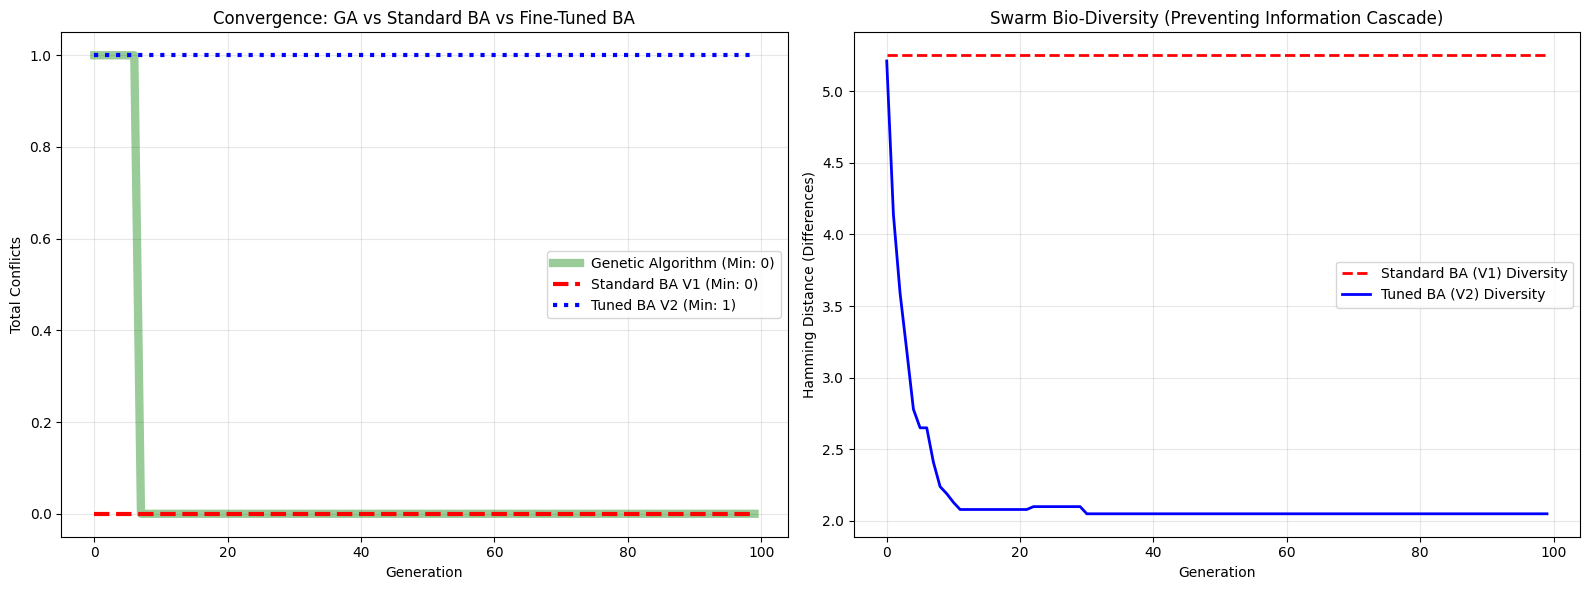

In [10]:
print("1. Generating Heuristic Population...")
smart_pop = smart_initialization(pop_size=POPULATION_SIZE, n_queens=N_QUEENS)

print("2. Running Baseline Genetic Algorithm...")
ga_best, ga_conv = genetic_algorithm()

print("3. Running Standard BA (V1)...")
ba_v1_best, ba_v1_conv, ba_v1_div = standard_bat_algorithm()

print("4. Running Fine-Tuned BA (V2)...")
ba_v2_best, ba_v2_conv, ba_v2_div = enhanced_bat_algorithm(
    init_pop=smart_pop, 
    a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
    f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA
)

print("\n--- Plotting Results ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ga_conv, label=f'Genetic Algorithm (Min: {ga_best})', color='green', linewidth=6, alpha=0.4)
ax1.plot(ba_v1_conv, label=f'Standard BA V1 (Min: {ba_v1_best})', color='red', linestyle='--', linewidth=3)
ax1.plot(ba_v2_conv, label=f'Tuned BA V2 (Min: {ba_v2_best})', color='blue', linestyle=':', linewidth=3)
ax1.set_title("Convergence: GA vs Standard BA vs Fine-Tuned BA")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Total Conflicts")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(ba_v1_div, label='Standard BA (V1) Diversity', color='red', linestyle='--', linewidth=2)
ax2.plot(ba_v2_div, label='Tuned BA (V2) Diversity', color='blue', linewidth=2)
ax2.set_title("Swarm Bio-Diversity (Preventing Information Cascade)")
ax2.set_xlabel("Generation")
ax2.set_ylabel("Hamming Distance (Differences)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Generating Bio-Diversity Matrix (Standard BA)...


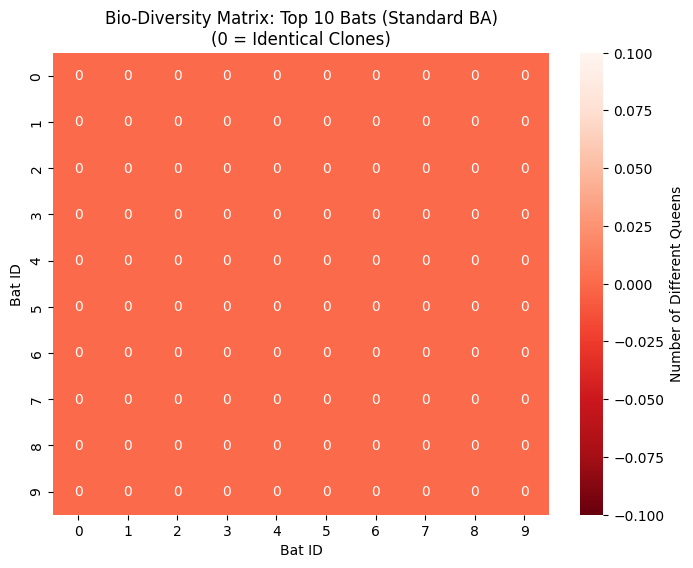

CONCLUSION: Out of the Top 10 Bats, there are only 1 unique physical configurations.


In [11]:
print("Generating Bio-Diversity Matrix (Standard BA)...")

pop_size_matrix = 20
positions_matrix = np.array([np.random.permutation(N_QUEENS) for _ in range(pop_size_matrix)], dtype=float)
velocities_matrix = np.zeros((pop_size_matrix, N_QUEENS))
best_pos = positions_matrix[0].copy()

for gen in range(50):
    for i in range(pop_size_matrix):
        velocities_matrix[i] += (positions_matrix[i] - best_pos) * random.uniform(0, 2.0)
        positions_matrix[i] = positions_matrix[i] + velocities_matrix[i]  # SYNTAX ERROR FIXED HERE
        
        if fitness_n_queens(positions_matrix[i]) < fitness_n_queens(best_pos):
            best_pos = positions_matrix[i].copy()

snapped_pop = np.round(positions_matrix) % N_QUEENS
fitness_scores = [fitness_n_queens(p) for p in snapped_pop]

top_10_indices = np.argsort(fitness_scores)[:10]
top_10_bats = snapped_pop[top_10_indices]

dist_matrix = squareform(pdist(top_10_bats, metric='hamming')) * N_QUEENS

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, cmap="Reds_r", cbar_kws={'label': 'Number of Different Queens'})
plt.title("Bio-Diversity Matrix: Top 10 Bats (Standard BA)\n(0 = Identical Clones)")
plt.xlabel("Bat ID")
plt.ylabel("Bat ID")
plt.show()

unique_bats = np.unique(top_10_bats, axis=0)
print(f"CONCLUSION: Out of the Top 10 Bats, there are only {len(unique_bats)} unique physical configurations.")

In [12]:
print("==================================================")
print("   SCALABILITY STRESS TEST (V2: TUNED + SMART)    ")
print("==================================================")

board_sizes = [4, 5, 6, 7, 8]
runs_per_size = 10
results = []

for size in board_sizes:
    print(f"\n[>>>] Stressing {size}x{size} Board (Constrained Population: 20)...")
    successes = 0
    gens_to_solve = []
    start_time = time.time()
    
    for run in range(runs_per_size):
        test_pop = smart_initialization(pop_size=20, n_queens=size)
        
        best_val, c_min, _ = enhanced_bat_algorithm(
            n_queens=size, pop_size=20, max_gens=150, 
            a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
            f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA, 
            init_pop=test_pop
        )
        
        if best_val == 0:
            successes += 1
            gen_solved = next((i for i, x in enumerate(c_min) if x == 0), 150)
            gens_to_solve.append(gen_solved)
            print(f"      Run {run+1}/10: [SUCCESS] Solved in {gen_solved} generations.")
        else:
            print(f"      Run {run+1}/10: [TRAPPED] Local optima ({best_val} conflicts).")
            
    exec_time = time.time() - start_time
    success_rate = (successes / runs_per_size) * 100
    avg_gens = np.mean(gens_to_solve) if successes > 0 else "N/A"
    
    results.append([
        f"{size}x{size}", 
        f"{success_rate}%", 
        f"{avg_gens:.1f}" if isinstance(avg_gens, float) else "N/A", 
        f"{exec_time:.2f}s"
    ])

print("\n--- FINAL SCALABILITY METRICS ---")
header = f"{'Board Size':<12} | {'Success Rate':<15} | {'Avg Gens to Solve':<18} | {'Total Exec Time'}"
print("-" * len(header))
print(header)
print("-" * len(header))
for row in results:
    print(f"{row[0]:<12} | {row[1]:<15} | {row[2]:<18} | {row[3]}")
print("-" * len(header))

   SCALABILITY STRESS TEST (V2: TUNED + SMART)    

[>>>] Stressing 4x4 Board (Constrained Population: 20)...
      Run 1/10: [SUCCESS] Solved in 0 generations.
      Run 2/10: [SUCCESS] Solved in 0 generations.
      Run 3/10: [SUCCESS] Solved in 0 generations.
      Run 4/10: [SUCCESS] Solved in 0 generations.
      Run 5/10: [SUCCESS] Solved in 0 generations.
      Run 6/10: [SUCCESS] Solved in 0 generations.
      Run 7/10: [SUCCESS] Solved in 0 generations.
      Run 8/10: [SUCCESS] Solved in 0 generations.
      Run 9/10: [SUCCESS] Solved in 0 generations.
      Run 10/10: [SUCCESS] Solved in 0 generations.

[>>>] Stressing 5x5 Board (Constrained Population: 20)...
      Run 1/10: [SUCCESS] Solved in 0 generations.
      Run 2/10: [SUCCESS] Solved in 0 generations.
      Run 3/10: [SUCCESS] Solved in 0 generations.
      Run 4/10: [SUCCESS] Solved in 0 generations.
      Run 5/10: [SUCCESS] Solved in 0 generations.
      Run 6/10: [SUCCESS] Solved in 0 generations.
      Run 7/10